In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Magic plt command for interactive plotting in Jupyter notebooks
%matplotlib widget

# Soles' pressure

## Basic metrics
L and R:
- total force
- center of pressure (on a 1*1 scale, to be re-scaled to foot dimension)

In [3]:
if os.getcwd().endswith("Code"):
    os.chdir("..")

fNamerecord = '20251201/semelles/jsing112-02.txt' 

soles = pd.read_csv(fNamerecord, delimiter='\t', header=9)

print(soles.columns.tolist())
soles.head()


['# time', 'left pressure 1[N/cm²]', 'left pressure 2[N/cm²]', 'left pressure 3[N/cm²]', 'left pressure 4[N/cm²]', 'left pressure 5[N/cm²]', 'left pressure 6[N/cm²]', 'left pressure 7[N/cm²]', 'left pressure 8[N/cm²]', 'left pressure 9[N/cm²]', 'left pressure 10[N/cm²]', 'left pressure 11[N/cm²]', 'left pressure 12[N/cm²]', 'left pressure 13[N/cm²]', 'left pressure 14[N/cm²]', 'left pressure 15[N/cm²]', 'left pressure 16[N/cm²]', 'left acceleration X[g]', 'left acceleration Y[g]', 'left acceleration Z[g]', 'left angular X[dps]', 'left angular Y[dps]', 'left angular Z[dps]', 'left total force[N]', 'left center of pressure X[-0.5...+0.5]', 'left center of pressure Y[-0.5...+0.5]', 'right pressure 1[N/cm²]', 'right pressure 2[N/cm²]', 'right pressure 3[N/cm²]', 'right pressure 4[N/cm²]', 'right pressure 5[N/cm²]', 'right pressure 6[N/cm²]', 'right pressure 7[N/cm²]', 'right pressure 8[N/cm²]', 'right pressure 9[N/cm²]', 'right pressure 10[N/cm²]', 'right pressure 11[N/cm²]', 'right pressu

,# time,left pressure 1[N/cm²],left pressure 2[N/cm²],left pressure 3[N/cm²],left pressure 4[N/cm²],left pressure 5[N/cm²],left pressure 6[N/cm²],left pressure 7[N/cm²],left pressure 8[N/cm²],left pressure 9[N/cm²],...,right pressure 16[N/cm²],right acceleration X[g],right acceleration Y[g],right acceleration Z[g],right angular X[dps],right angular Y[dps],right angular Z[dps],right total force[N],right center of pressure X[-0.5...+0.5],right center of pressure Y[-0.5...+0.5]
0,0.00,12.0,10.75,4.50,7.00,0.75,3.75,0.25,4.00,0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.01,12.0,9.75,4.75,6.75,0.75,4.00,0.25,4.00,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02,12.0,11.00,4.75,6.75,1.00,3.50,0.25,4.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.03,12.0,10.75,4.75,7.00,1.00,3.50,0.25,3.75,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.04,12.0,10.75,4.75,6.75,1.00,4.00,0.00,4.00,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


       # time  left total force[N]
0        0.00                634.0
1        0.01                624.0
2        0.02                629.0
3        0.03                632.0
4        0.04                639.0
...       ...                  ...
11209  112.10                  NaN
11210  112.11                  NaN
11211  112.12                  NaN
11212  112.13                  NaN
11213  112.14                  NaN

[11214 rows x 2 columns]


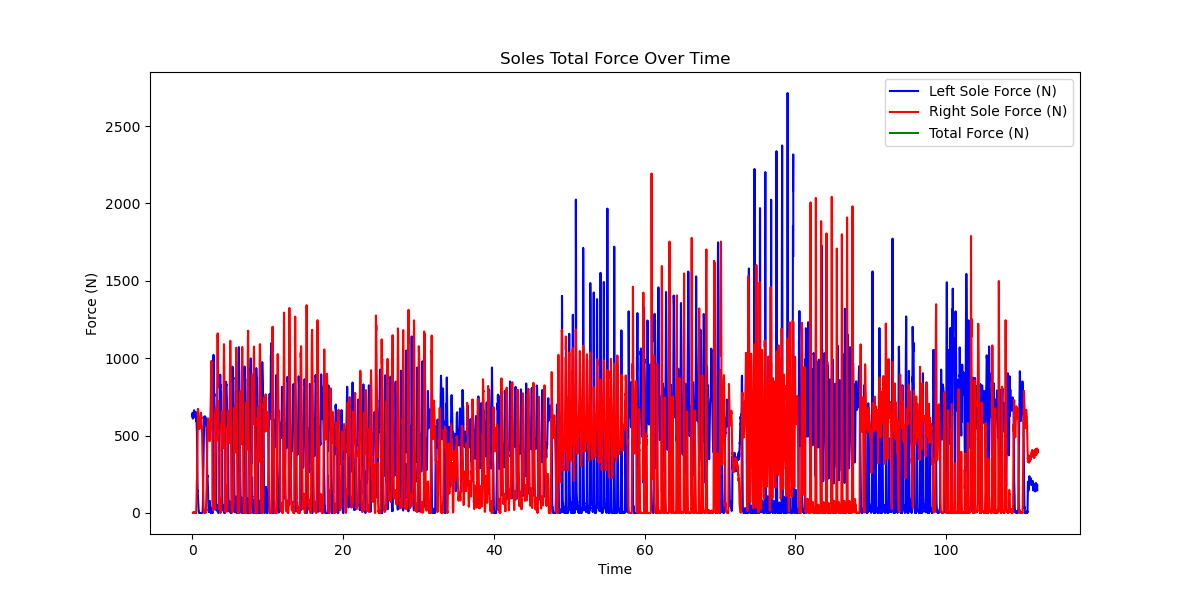

In [4]:
l_force = soles[['# time','left total force[N]']]
r_force = soles[['# time','right total force[N]']]
tot_force = l_force + r_force

print(l_force)

plt.figure(figsize=(12, 6))
plt.plot(l_force.iloc[:, 0], l_force.iloc[:, 1], label='Left Sole Force (N)', color='blue')
plt.plot(r_force.iloc[:, 0], r_force.iloc[:, 1], label='Right Sole Force (N)', color='red')
plt.plot(tot_force.iloc[:, 0], tot_force.iloc[:, 1], label='Total Force (N)', color='green')
plt.title('Soles Total Force Over Time')
plt.xlabel('Time')
plt.ylabel('Force (N)')
plt.legend()
plt.show()

[[ 0.00000e+00 -1.72797e-01]
 [ 1.00000e-02 -1.71249e-01]
 [ 2.00000e-02 -1.78330e-01]
 ...
 [ 1.12120e+02          nan]
 [ 1.12130e+02          nan]
 [ 1.12140e+02          nan]]


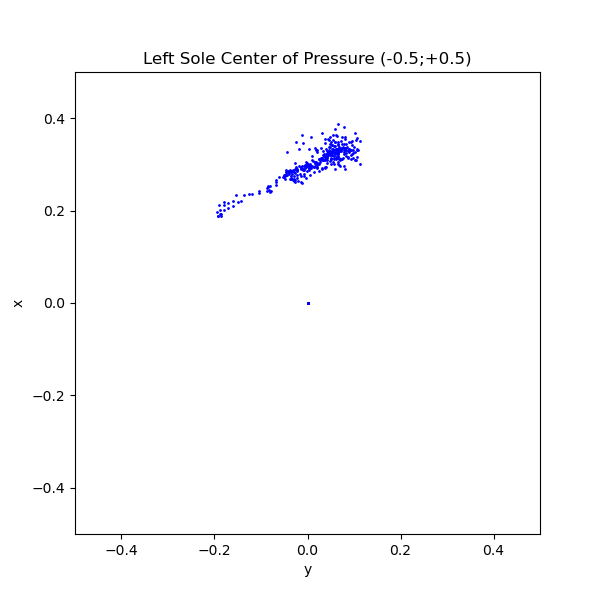

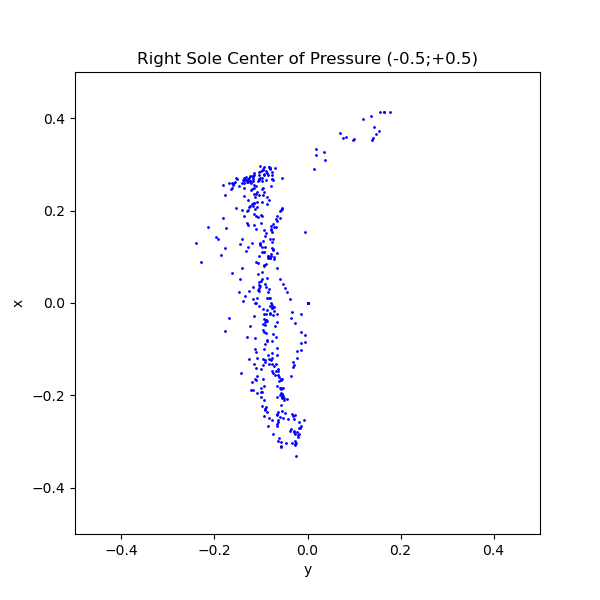

In [24]:
l_cop_x = np.array(soles[['# time', 'left center of pressure X[-0.5...+0.5]']])
l_cop_y = np.array(soles[['# time', 'left center of pressure Y[-0.5...+0.5]']])

r_cop_x = np.array(soles[['# time', 'right center of pressure X[-0.5...+0.5]']])
r_cop_y = np.array(soles[['# time', 'right center of pressure Y[-0.5...+0.5]']])

print(l_cop_x)

mask = (l_cop_x[:, 0] >= 2.983) & (l_cop_x[:, 0] <= 8.917)

plt.figure(figsize=(6, 6))
plt.plot(l_cop_y[mask, 1], l_cop_x[mask, 1], color='blue', linestyle = 'None', marker='o', markersize = 1)
plt.title('Left Sole Center of Pressure (-0.5;+0.5)')
plt.xlabel('y')
plt.ylabel('x')
plt.xlim([-0.5, 0.5])
plt.ylim([-0.5, 0.5])
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(r_cop_y[mask, 1], r_cop_x[mask, 1], color='blue', linestyle = 'None', marker='o', markersize = 1)
plt.title('Right Sole Center of Pressure (-0.5;+0.5)')
plt.xlabel('y')
plt.ylabel('x')
plt.xlim([-0.5, 0.5])
plt.ylim([-0.5, 0.5])
plt.show()


### Re-scale to mm

Sole size: S5
Sole width: 93.8 ± 1.5 mm
Sole length: 261.1 ± 1.5 mm


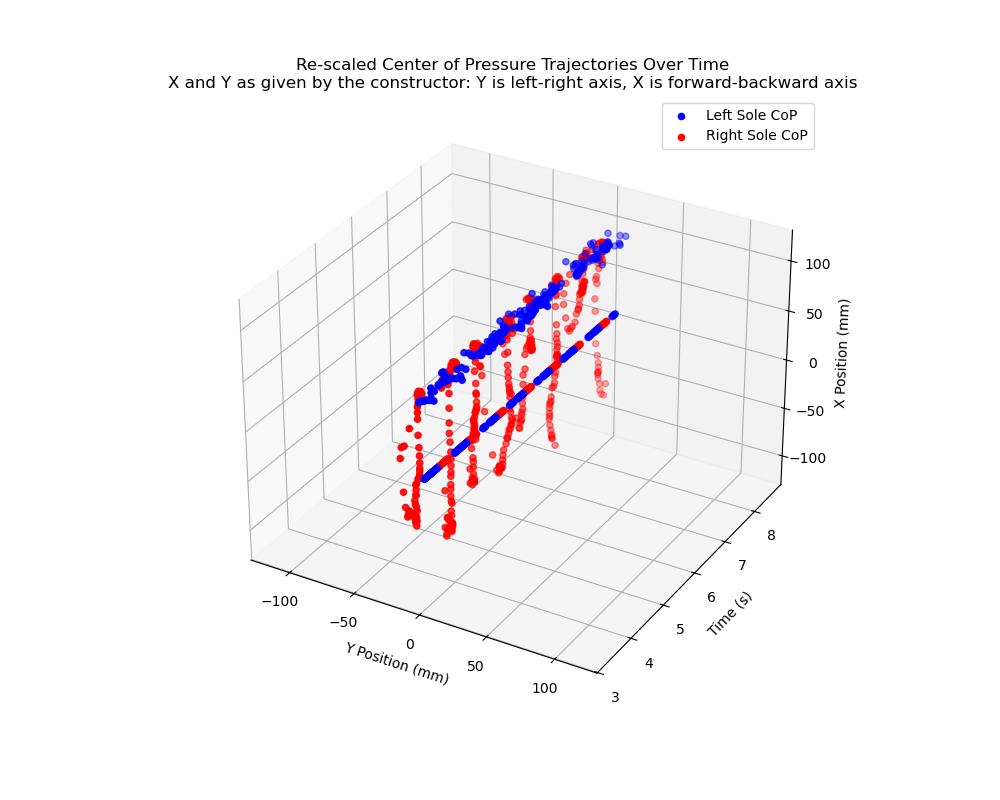

In [32]:
# Soles' dimensions (https://moticon.com/opengo/sensor-insole-sizes)
soles_dimensions = np.array([  # row: sole; 1st col: width; 2nd col: length
    [80.2,214.9],
    [83.4,225.6],
    [86.7,236.8],
    [90.2,248.6],
    [93.8,261.1],
    [97.50,274.2],
    [101.4,288.0],
    [105.5,302.4],
    [109.7,317.5]
])

sole_size = 5

for i in range(soles_dimensions.shape[0]):
    if sole_size == i:
        sole_width = soles_dimensions[i-1,0]
        sole_length = soles_dimensions[i-1,1]
    else:
        i = i+1

print(f"Sole size: S{sole_size}\nSole width: {sole_width} \u00B1 1.5 mm\nSole length: {sole_length} \u00B1 1.5 mm")

# Re-scaling
l_cop_x_rescaled = l_cop_x * sole_length
l_cop_y_rescaled = l_cop_y * sole_width

r_cop_x_rescaled = r_cop_x * sole_length
r_cop_y_rescaled = r_cop_y * sole_width

# Plotting the re-scaled CoP trajectories in 3D, with time as the y-axis (z-axis is the x values, x-axis is the y values)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(l_cop_y_rescaled[mask, 1], soles['# time'][mask], l_cop_x_rescaled[mask, 1], color='blue', label='Left Sole CoP')
ax.scatter(r_cop_y_rescaled[mask, 1], soles['# time'][mask], r_cop_x_rescaled[mask, 1], color='red', label='Right Sole CoP')
ax.set_title('Re-scaled Center of Pressure Trajectories Over Time\nX and Y as given by the constructor: Y is left-right axis, X is forward-backward axis')
ax.set_xlabel('Y Position (mm)')
ax.set_ylabel('Time (s)')
ax.set_zlabel('X Position (mm)')
ax.set_xlim([-sole_length/2, sole_length/2])
ax.set_ylim([2.983, 8.917])
ax.set_zlim([-sole_length/2, sole_length/2])
ax.legend()
plt.show()


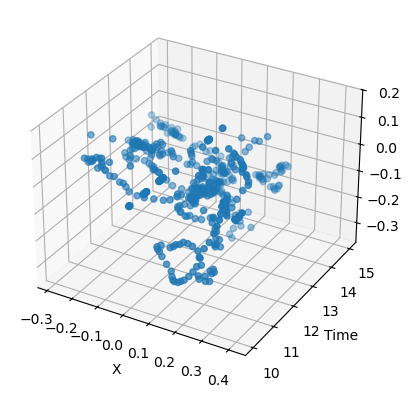

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(l_cop_x[1000:1500], soles['# time'][1000:1500], l_cop_y[1000:1500])

ax.set_xlabel('X')
ax.set_ylabel('Time')
ax.set_zlabel('Y')

plt.show()

## Comparison of feet position estimated by Awinda and soles
Integration of acceleration on x, y, z for both soles.

# sEMG

## EMG ant delt r

In [ ]:
fNameEMG = '20251201/sEMG/EMG_IMU_Delsys_2_technique_paos.csv' 

emg = pd.read_csv(fNameEMG, delimiter=',', header=79)

print(emg.columns.tolist())
emg.head()

['X[s]', 'Avanti sensor 1: EMG 1', 'X[s].1', 'Avanti sensor 1: ACC.X 1', 'X[s].2', 'Avanti sensor 1: ACC.Y 1', 'X[s].3', 'Avanti sensor 1: ACC.Z 1', 'X[s].4', 'Avanti sensor 1: GYRO.X 1', 'X[s].5', 'Avanti sensor 1: GYRO.Y 1', 'X[s].6', 'Avanti sensor 1: GYRO.Z 1', 'X[s].7', 'Avanti sensor 2: EMG 2', 'X[s].8', 'Avanti sensor 2: ACC.X 2', 'X[s].9', 'Avanti sensor 2: ACC.Y 2', 'X[s].10', 'Avanti sensor 2: ACC.Z 2', 'X[s].11', 'Avanti sensor 2: GYRO.X 2', 'X[s].12', 'Avanti sensor 2: GYRO.Y 2', 'X[s].13', 'Avanti sensor 2: GYRO.Z 2', 'X[s].14', 'Avanti sensor 3: EMG 3', 'X[s].15', 'Avanti sensor 3: ACC.X 3', 'X[s].16', 'Avanti sensor 3: ACC.Y 3', 'X[s].17', 'Avanti sensor 3: ACC.Z 3', 'X[s].18', 'Avanti sensor 3: GYRO.X 3', 'X[s].19', 'Avanti sensor 3: GYRO.Y 3', 'X[s].20', 'Avanti sensor 3: GYRO.Z 3', 'X[s].21', 'Avanti sensor 4: EMG 4', 'X[s].22', 'Avanti sensor 4: ACC.X 4', 'X[s].23', 'Avanti sensor 4: ACC.Y 4', 'X[s].24', 'Avanti sensor 4: ACC.Z 4', 'X[s].25', 'Avanti sensor 4: GYRO.X

,X[s],Avanti sensor 1: EMG 1,X[s].1,Avanti sensor 1: ACC.X 1,X[s].2,Avanti sensor 1: ACC.Y 1,X[s].3,Avanti sensor 1: ACC.Z 1,X[s].4,Avanti sensor 1: GYRO.X 1,...,X[s].72,Avanti sensor 11: ACC.Y 11,X[s].73,Avanti sensor 11: ACC.Z 11,X[s].74,Avanti sensor 11: GYRO.X 11,X[s].75,Avanti sensor 11: GYRO.Y 11,X[s].76,Avanti sensor 11: GYRO.Z 11
0,0.000000,0.000023,0.00000,-0.000488,0.00000,-1.005371,0.00000,-0.057129,0.00000,-9.268292,...,0.00000,0.165527,0.00000,0.168945,0.00000,-4.695122,0.00000,6.768293,0.00000,-17.74390
1,0.000794,0.000030,0.00675,-0.002441,0.00675,-1.005371,0.00675,-0.053711,0.00675,-9.512196,...,0.00675,0.174316,0.00675,0.164062,0.00675,-6.097561,0.00675,6.341464,0.00675,-18.47561
2,0.001588,0.000035,0.01350,0.005859,0.01350,-1.004883,0.01350,-0.056152,0.01350,-9.817074,...,0.01350,0.174805,0.01350,0.138672,0.01350,-6.890244,0.01350,4.695122,0.01350,-20.00000
3,0.002382,0.000036,0.02025,0.013184,0.02025,-1.002441,0.02025,-0.060059,0.02025,-9.756098,...,0.02025,0.163086,0.02025,0.143555,0.02025,-9.390244,0.02025,6.585366,0.02025,-18.17073
4,0.003176,0.000032,0.02700,0.016113,0.02700,-1.003418,0.02700,-0.066406,0.02700,-10.121950,...,0.02700,0.149414,0.02700,0.150879,0.02700,-10.975610,0.02700,6.402439,0.02700,-17.43902


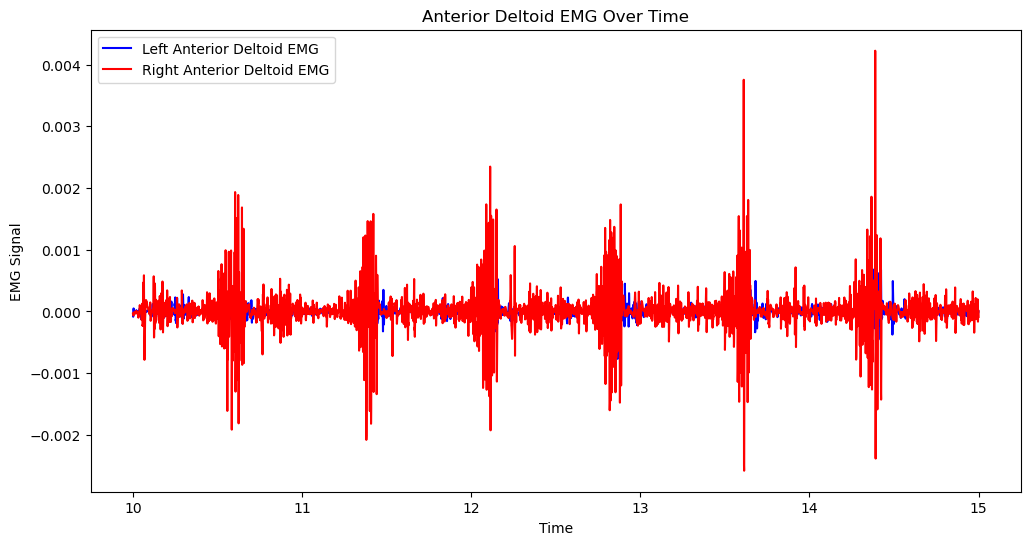

In [ ]:
emg_ant_delt_r = emg['Avanti sensor 10: EMG 10']
emg_ant_delt_l = emg['Avanti sensor 11: EMG 11']  # 9 became 11 because we replaced the original sensor by the erect spin one (mini Trigno) (so no erect spin)

# 10->15 sec interval: right crosses
t_10_15 = (emg['X[s]'] >= 10) & (emg['X[s]'] <= 15)

plt.figure(figsize=(12, 6))
plt.plot(emg['X[s]'][t_10_15], emg_ant_delt_l[t_10_15], label='Left Anterior Deltoid EMG', color='blue')
plt.plot(emg['X[s]'][t_10_15], emg_ant_delt_r[t_10_15], label='Right Anterior Deltoid EMG', color='red')
plt.title('Anterior Deltoid EMG Over Time')
plt.xlabel('Time')
plt.ylabel('EMG Signal')
plt.legend()
plt.show()

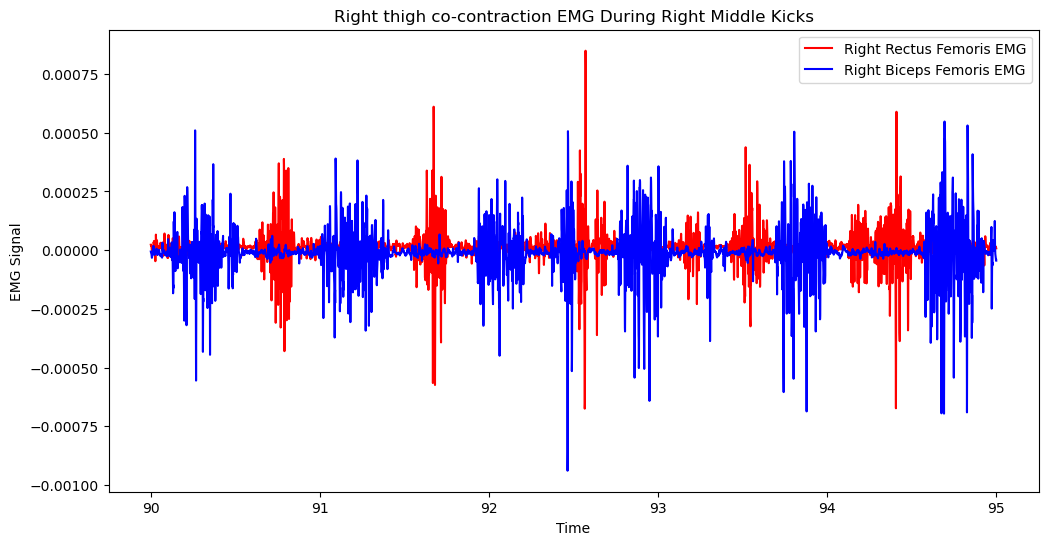

In [ ]:
emg_rect_fem_r = emg['Avanti sensor 6: EMG 6']
emg_bic_fem_r = emg['Avanti sensor 4: EMG 4']

# 90->95 sec interval: right circular middle kicks
t_90_95 = (emg['X[s]'] >= 90) & (emg['X[s]'] <= 95)

plt.figure(figsize=(12, 6))
plt.plot(emg['X[s]'][t_90_95], emg_rect_fem_r[t_90_95], label='Right Rectus Femoris EMG', color='red')
plt.plot(emg['X[s]'][t_90_95], emg_bic_fem_r[t_90_95], label='Right Biceps Femoris EMG', color='blue')
plt.title('Right thigh co-contraction EMG During Right Middle Kicks')
plt.xlabel('Time')
plt.ylabel('EMG Signal')
plt.legend()
plt.show()

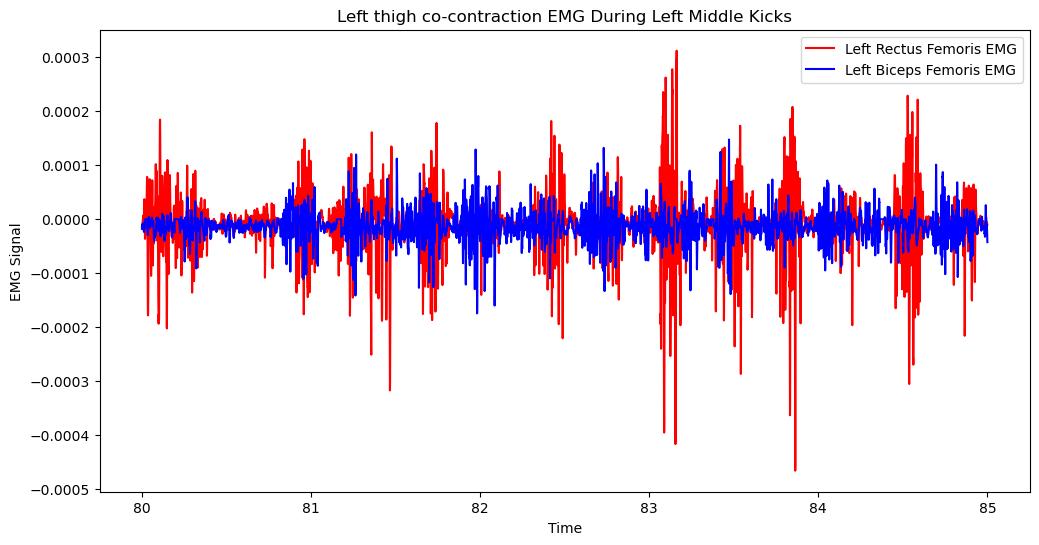

In [ ]:
emg_rect_fem_l = emg['Avanti sensor 5: EMG 5']
emg_bic_fem_l = emg['Avanti sensor 3: EMG 3']

# 80->85 sec interval: right circular middle kicks
t_80_85 = (emg['X[s]'] >= 80) & (emg['X[s]'] <= 85)

plt.figure(figsize=(12, 6))
plt.plot(emg['X[s]'][t_80_85], emg_rect_fem_l[t_80_85], label='Left Rectus Femoris EMG', color='red')
plt.plot(emg['X[s]'][t_80_85], emg_bic_fem_l[t_80_85], label='Left Biceps Femoris EMG', color='blue')
plt.title('Left thigh co-contraction EMG During Left Middle Kicks')
plt.xlabel('Time')
plt.ylabel('EMG Signal')
plt.legend()
plt.show()